In [2]:
import corner
import matplotlib.pyplot as pl
import numpy as np
import os
from astropy.io import fits 

indir = '/home/ubuntu/work/lcretrieval/JWST_data/HD209458b/results-260421-pix/'
infile  = os.path.join(indir, 'HD209458b.fits')

with fits.open(infile) as hdul:
    header = hdul['MCMC'].header
    data = hdul['MCMC'].data
    postsamples = np.column_stack([data[name] for name in data.dtype.names])
    pnames = [name for name in data.dtype.names]


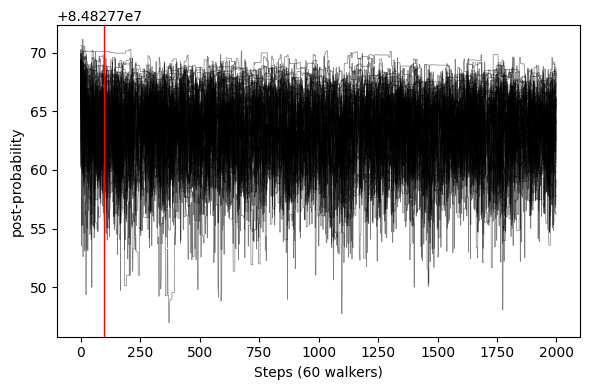

In [3]:
infile = indir + 'lnprob.txt'
burnin = 100

lnprobs = np.loadtxt(infile)
maxlike_params = postsamples[lnprobs.flatten().argmax()] 

fig, ax = pl.subplots(1,1,figsize=(6,4))
ax.plot(lnprobs, c='k', lw=0.5, alpha=0.5)
ax.axvline(burnin, c='r', lw=1)
ax.set_xlabel(f'Steps ({lnprobs.shape[1]} walkers)')
ax.set_ylabel('post-probability')
fig.tight_layout()

In [4]:
# s = postsamples[np.where(lnprobs.flatten() > 84827740)[0]]
s = postsamples[lnprobs.shape[1]*burnin:, :]  

fig = corner.corner(
    s, labels=pnames,
    truths=maxlike_params, 
    range=0.999*np.ones(s.shape[1]),
    levels=[0.3935, 0.8647, 0.9889],
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True, title_fmt='.4g',
    plot_datapoints=False, plot_density=True,
)
fig.savefig('corner_plot-new.pdf')
pl.close(fig)


In [5]:
print("Max-Likelihood parameters:")
for n in pnames:
    print(f"{n}: {maxlike_params[pnames.index(n)]:.6g}") 

Max-Likelihood parameters:
rho: 1.04399
p: 3.52475
b: 0.507245
tc_00: 2.45989e+06
teff: 6000
logg: 4.48956
metal: -0.118125
mp: 0.828351
ref_p: 1.46217
cloud_p: -0.989519
kir: -3.43477
gamma: 0.154312
tint: 464.207
m2h: 1.68743
c2o: 0.101954
sigma_m_00: 1.10001
sigma_m_01: 1.02419
